## convert a phone video

In [2]:
# convert a phone video to constant 30 fps
!ffmpeg -i /kaggle/input/datasets/dinethm/bed-monitor-sample/0000.mp4 -vf fps=30 -c:v libx264 -crf 20 -an output_cfr.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## 1: Logging setup

In [4]:
import logging, sys
from pathlib import Path

LOG_FORMAT = "%(asctime)s | %(levelname)-7s | %(name)s | %(message)s"
DATE_FORMAT = "%H:%M:%S"

def get_logger(name: str = "bedmonitor", level: int = logging.INFO) -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(level)
    logger.propagate = False  # stops duplicate lines
    if not logger.handlers:
        handler = logging.StreamHandler(sys.stdout)
        handler.setFormatter(logging.Formatter(LOG_FORMAT, DATE_FORMAT))
        logger.addHandler(handler)
    return logger

def add_file_handler(logger: logging.Logger, log_path) -> None:
    log_path = Path(log_path).resolve()
    log_path.parent.mkdir(parents=True, exist_ok=True)
    for h in logger.handlers:
        if isinstance(h, logging.FileHandler) and Path(h.baseFilename) == log_path:
            return
    fh = logging.FileHandler(log_path, encoding="utf-8")
    fh.setFormatter(logging.Formatter(LOG_FORMAT, DATE_FORMAT))
    logger.addHandler(fh)

log = get_logger()                              # main logger
video_log = logging.getLogger("bedmonitor.video")   # child logger for video code

## 2: Environment check

In [5]:
import platform, os

IN_KAGGLE = os.path.exists("/kaggle/working")
IN_COLAB = "google.colab" in sys.modules

log.info("Python %s", platform.python_version())
log.info("Platform: %s", "Kaggle" if IN_KAGGLE else "Colab" if IN_COLAB else "Local")

try:
    import torch
    log.info("Torch %s", torch.__version__)
    if torch.cuda.is_available():
        log.info("GPU: %s", torch.cuda.get_device_name(0))
    else:
        log.warning("No GPU found")
except ImportError:
    log.warning("Torch is not installed")

17:54:01 | INFO    | bedmon | Python 3.12.13
17:54:01 | INFO    | bedmon | Platform: Kaggle
17:54:06 | INFO    | bedmon | Torch 2.10.0+cpu
17:54:06 | WARNING | bedmon | No GPU found


## 3: Install packages

In [6]:
!pip install -q -U ultralytics opencv-python-headless pandas pyarrow pyyaml
!pip freeze > /tmp/requirements_run.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 706.3 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 25.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 78.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 29.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 2.3 MB/s eta 0:00:00eta 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-

## 4: Paths and config

In [8]:
from dataclasses import dataclass, asdict
import json

if IN_KAGGLE:
    BASE_DIR = Path("/kaggle/working")
elif IN_COLAB:
    BASE_DIR = Path("/content")
else:
    BASE_DIR = Path.cwd()

@dataclass
class Config:
    video_path: str = ""
    output_dir: str = str(BASE_DIR / "outputs")

    # Frame sampling
    sample_fps: float = 4.0     # frames per second to analyze
    max_side: int = 1280        # resize so the longest side is at most this

    # Models
    pose_model: str = "yolo26n-pose.pt"
    tracker: str = "botsort.yaml"

    def save(self, path: Path):
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2))
        log.info("Config saved to %s", path)

cfg = Config(video_path="/kaggle/input/datasets/dinethm/bed-monitor-sample/0000.mp4")
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
add_file_handler(log, Path(cfg.output_dir) / "run.log")

log.info("Output folder: %s", cfg.output_dir)
log.info("Config: %s", asdict(cfg))

17:55:21 | INFO    | bedmon | Output folder: /kaggle/working/outputs
17:55:21 | INFO    | bedmon | Config: {'video_path': '/kaggle/input/datasets/dinethm/bed-monitor-sample/0000.mp4', 'output_dir': '/kaggle/working/outputs', 'sample_fps': 4.0, 'max_side': 1280, 'pose_model': 'yolo26n-pose.pt', 'tracker': 'botsort.yaml'}


## 5: Time helpers

In [9]:
def fmt_time(sec: float) -> str:
    """Seconds to 'HH:MM:SS'"""
    sec = int(round(sec))
    h, rem = divmod(sec, 3600)
    m, s = divmod(rem, 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

def fmt_duration(sec: float) -> str:
    """Seconds to '11m 42s' style"""
    sec = int(round(sec))
    m, s = divmod(sec, 60)
    return f"{m}m {s:02d}s" if m else f"{s}s"

## 6: Read video metadata

In [10]:
import cv2

@dataclass
class VideoInfo:
    path: str
    fps: float
    frame_count: int
    width: int
    height: int
    duration_sec: float

def probe_video(path: str) -> VideoInfo:
    """Read basic video info. Fails early if the file cannot be used."""
    video_log.info("Opening video: %s", path)

    if not Path(path).exists():
        video_log.error("File not found: %s", path)
        raise FileNotFoundError(f"Video not found: {path}")

    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        video_log.error("OpenCV cannot open the file: %s", path)
        raise IOError(f"OpenCV cannot open: {path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    if fps is None or fps <= 0 or fps > 240:
        video_log.error("Bad fps value: %s. Convert the video with ffmpeg.", fps)
        raise ValueError(f"Bad fps value ({fps}).")

    if frame_count <= 0:
        video_log.error("Bad frame count: %s. Convert the video with ffmpeg.", frame_count)
        raise ValueError(f"Bad frame count ({frame_count}).")

    info = VideoInfo(
        path=path,
        fps=fps,
        frame_count=frame_count,
        width=width,
        height=height,
        duration_sec=frame_count / fps,
    )
    video_log.info(
        "Video: %dx%d, %.2f fps, %d frames, duration %s",
        width, height, fps, frame_count, fmt_time(info.duration_sec),
    )
    return info

info = probe_video(cfg.video_path)

17:57:02 | INFO    | bedmon.video | Opening video: /kaggle/input/datasets/dinethm/bed-monitor-sample/0000.mp4
17:57:02 | INFO    | bedmon.video | Video: 1280x720, 29.82 fps, 356 frames, duration 00:00:12


## 7: Frame sampler

In [14]:
import time
import numpy as np
from typing import Iterator

@dataclass
class SampledFrame:
    sample_idx: int      # 0, 1, 2, ... in the sampled sequence
    frame_idx: int       # index in the original video
    t_sec: float         # timestamp in seconds
    image: np.ndarray    # BGR image (OpenCV format)

def resize_max_side(img: np.ndarray, max_side: int) -> np.ndarray:
    h, w = img.shape[:2]
    scale = max_side / max(h, w)
    if scale >= 1.0:
        return img
    return cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

def sample_frames(
    info: VideoInfo,
    sample_fps: float,
    max_side: int = 1280,
    start_sec: float = 0.0,
    end_sec: float | None = None,
    log_every_sec: float = 60.0,
) -> Iterator[SampledFrame]:
    """
    Read the video in order and keep frames at `sample_fps`.
    Timestamps come from frame_index / native_fps, so the video must be constant fps.
    `grab()` skips decoding work for frames we do not keep.
    Logs progress every `log_every_sec` seconds of video.
    """
    if sample_fps <= 0:
        video_log.error("sample_fps must be > 0 (got %s)", sample_fps)
        raise ValueError("sample_fps must be > 0")

    if sample_fps > info.fps:
        video_log.warning(
            "sample_fps %.2f is above video fps %.2f. Using %.2f.",
            sample_fps, info.fps, info.fps,
        )
        sample_fps = info.fps

    end_sec = info.duration_sec if end_sec is None else min(end_sec, info.duration_sec)
    if start_sec >= end_sec:
        video_log.error("start_sec (%.2f) must be before end_sec (%.2f)", start_sec, end_sec)
        raise ValueError("start_sec must be before end_sec")

    video_log.info(
        "Sampling %s -> %s at %.2f fps (max_side=%d)",
        fmt_time(start_sec), fmt_time(end_sec), sample_fps, max_side,
    )

    cap = cv2.VideoCapture(info.path)
    start_frame = int(round(start_sec * info.fps))
    if start_frame > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        video_log.debug("Jumped to frame %d", start_frame)

    step = 1.0 / sample_fps
    next_t = start_sec
    frame_idx = start_frame
    sample_idx = 0
    last_t = None
    t_sec = start_sec
    next_log_t = start_sec + log_every_sec
    grab_failed = False
    decode_failures = 0
    wall_start = time.perf_counter()

    try:
        while True:
            t_sec = frame_idx / info.fps
            if t_sec > end_sec:
                break
            if not cap.grab():
                grab_failed = True
                break

            if t_sec + 1e-6 >= next_t:
                ok, img = cap.retrieve()
                if ok and img is not None:
                    frame = SampledFrame(
                        sample_idx=sample_idx,
                        frame_idx=frame_idx,
                        t_sec=round(t_sec, 3),
                        image=resize_max_side(img, max_side),
                    )
                    sample_idx += 1
                    last_t = t_sec
                    yield frame
                else:
                    decode_failures += 1
                    video_log.warning("Could not decode frame %d (t=%.2fs). Skipped.", frame_idx, t_sec)
                next_t += step

            if t_sec >= next_log_t:
                video_log.info(
                    "Progress: %s / %s (%d samples)",
                    fmt_time(t_sec), fmt_time(end_sec), sample_idx,
                )
                next_log_t += log_every_sec

            frame_idx += 1
    finally:
        cap.release()
        elapsed = time.perf_counter() - wall_start
        video_log.info(
            "Done: %d samples, last t=%.2fs, %.1fs elapsed",
            sample_idx, last_t if last_t is not None else -1, elapsed,
        )
        if decode_failures:
            video_log.warning("%d frames could not be decoded", decode_failures)
        if grab_failed and end_sec - t_sec > 1.0:
            video_log.warning(
                "Video ended early at %.2fs (expected %.2fs). The file may be damaged.",
                t_sec, end_sec,
            )

## 8: Quick check

17:57:46 | INFO    | bedmon.video | Sampling 00:00:00 -> 00:00:10 at 4.00 fps (max_side=1280)
17:57:48 | INFO    | bedmon.video | Done: 40 samples, last t=9.76s, 1.2s elapsed
17:57:48 | INFO    | bedmon | Sampled 40 frames from the first 10 s (expected about 41)


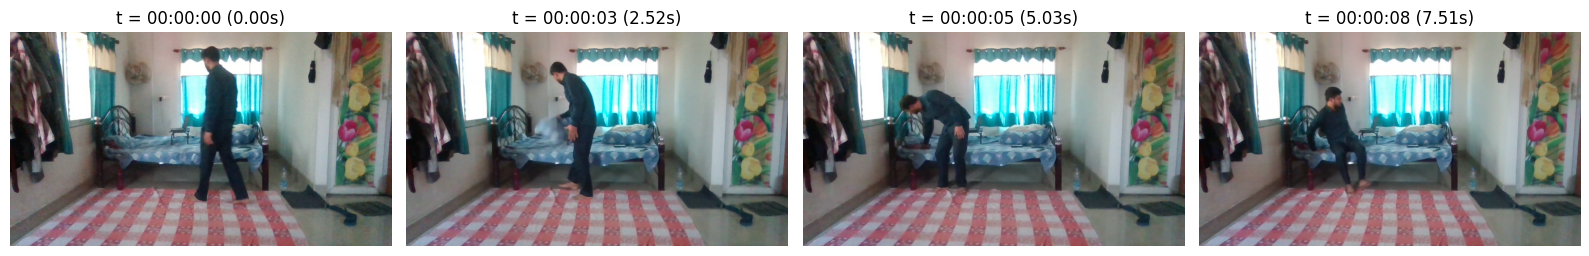

17:57:49 | INFO    | bedmon | Config saved to /kaggle/working/outputs/config.json


In [15]:
import matplotlib.pyplot as plt

frames = list(sample_frames(info, cfg.sample_fps, cfg.max_side, start_sec=0, end_sec=10))

expected = int(10 * min(cfg.sample_fps, info.fps)) + 1
log.info("Sampled %d frames from the first 10 s (expected about %d)", len(frames), expected)
if abs(len(frames) - expected) > 1:
    log.warning("Frame count differs from expected. Check the video fps.")

show = frames[:: max(1, len(frames) // 4)][:4]
fig, axes = plt.subplots(1, len(show), figsize=(4 * len(show), 3))
axes = np.atleast_1d(axes)
for ax, f in zip(axes, show):
    ax.imshow(cv2.cvtColor(f.image, cv2.COLOR_BGR2RGB))
    ax.set_title(f"t = {fmt_time(f.t_sec)} ({f.t_sec:.2f}s)")
    ax.axis("off")
plt.tight_layout()
plt.show()

cfg.save(Path(cfg.output_dir) / "config.json")